In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings

warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
emails = pd.read_csv("../dataset/emails.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", emails.shape)

display(emails.head())

Dataset loaded successfully!
Dataset shape: (517401, 2)


,file,message
0,allen-p/_sent_mail/1.,Message-ID: <18782981.1075855378110.JavaMail.e...
1,allen-p/_sent_mail/10.,Message-ID: <15464986.1075855378456.JavaMail.e...
2,allen-p/_sent_mail/100.,Message-ID: <24216240.1075855687451.JavaMail.e...
3,allen-p/_sent_mail/1000.,Message-ID: <13505866.1075863688222.JavaMail.e...
4,allen-p/_sent_mail/1001.,Message-ID: <30922949.1075863688243.JavaMail.e...


In [3]:
print("Dataset columns:")
print(emails.columns.tolist())

print("\nDataset information:")
print(emails.info())

print("\nMissing values:")
print(emails.isnull().sum())

print("\nDuplicate rows:")
print(emails.duplicated().sum())

Dataset columns:
['file', 'message']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517401 entries, 0 to 517400
Data columns (total 2 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   file     517401 non-null  object
 1   message  517401 non-null  object
dtypes: object(2)
memory usage: 7.9+ MB
None

Missing values:
file       0
message    0
dtype: int64

Duplicate rows:
0


In [4]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string
import re

# Download required NLTK resources
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")

# Keep only valid text messages
emails_clean = emails[emails["message"].notna()].copy()

# Convert messages to lowercase
emails_clean["clean_text"] = emails_clean["message"].str.lower()

# Remove punctuation
emails_clean["clean_text"] = emails_clean["clean_text"].apply(
    lambda text: text.translate(str.maketrans("", "", string.punctuation))
)

# Tokenization
emails_clean["tokens"] = emails_clean["clean_text"].apply(word_tokenize)

# Remove stopwords
stop_words = set(stopwords.words("english"))

emails_clean["filtered_tokens"] = emails_clean["tokens"].apply(
    lambda tokens: [word for word in tokens if word not in stop_words]
)

# Convert tokens back to text
emails_clean["processed_text"] = emails_clean["filtered_tokens"].apply(
    lambda tokens: " ".join(tokens)
)

print("NLP preprocessing completed successfully!")

display(
    emails_clean[["message", "processed_text"]].head(10)
)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\saisp\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\saisp\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\saisp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


NLP preprocessing completed successfully!


,message,processed_text
0,Message-ID: <18782981.1075855378110.JavaMail.e...,messageid 187829811075855378110javamailevansth...
1,Message-ID: <15464986.1075855378456.JavaMail.e...,messageid 154649861075855378456javamailevansth...
2,Message-ID: <24216240.1075855687451.JavaMail.e...,messageid 242162401075855687451javamailevansth...
3,Message-ID: <13505866.1075863688222.JavaMail.e...,messageid 135058661075863688222javamailevansth...
4,Message-ID: <30922949.1075863688243.JavaMail.e...,messageid 309229491075863688243javamailevansth...
5,Message-ID: <30965995.1075863688265.JavaMail.e...,messageid 309659951075863688265javamailevansth...
6,Message-ID: <16254169.1075863688286.JavaMail.e...,messageid 162541691075863688286javamailevansth...
7,Message-ID: <17189699.1075863688308.JavaMail.e...,messageid 171896991075863688308javamailevansth...
8,Message-ID: <20641191.1075855687472.JavaMail.e...,messageid 206411911075855687472javamailevansth...
9,Message-ID: <30795301.1075855687494.JavaMail.e...,messageid 307953011075855687494javamailevansth...


In [5]:
from collections import Counter, defaultdict

# Create a frequency-based bigram model
bigram_counts = defaultdict(Counter)

# Process the cleaned email text
for text in emails_clean["processed_text"]:
    words = text.split()

    for i in range(len(words) - 1):
        current_word = words[i]
        next_word = words[i + 1]
        bigram_counts[current_word][next_word] += 1

print("Bigram model created successfully!")
print("Number of words with next-word predictions:", len(bigram_counts))

Bigram model created successfully!
Number of words with next-word predictions: 1651227


In [6]:
def predict_next_word(word, top_n=3):
    word = word.lower().strip()

    if word not in bigram_counts:
        return []

    return [
        next_word
        for next_word, count in bigram_counts[word].most_common(top_n)
    ]

# Test the autocomplete model
test_word = "please"

print("Input word:", test_word)
print("Top 3 predictions:", predict_next_word(test_word, 3))

Input word: please
Top 3 predictions: ['let', 'contact', 'call']


In [8]:
# Step 6: Test autocomplete on 10 different input prefixes

test_prefixes = [
    "please",
    "thank",
    "hello",
    "would",
    "get",
    "need",
    "send",
    "information",
    "contact",
    "message"
]

results = []

for prefix in test_prefixes:
    predictions = predict_next_word(prefix, 3)

    results.append({
        "Input Prefix": prefix,
        "Prediction 1": predictions[0] if len(predictions) > 0 else "No prediction",
        "Prediction 2": predictions[1] if len(predictions) > 1 else "No prediction",
        "Prediction 3": predictions[2] if len(predictions) > 2 else "No prediction"
    })

autocomplete_results = pd.DataFrame(results)

display(autocomplete_results)

,Input Prefix,Prediction 1,Prediction 2,Prediction 3
0,please,let,contact,call
1,thank,much,participation,help
2,hello,everyone,vince,mimeversion
3,would,like,appreciate,also
4,get,back,free,together
5,need,get,know,help
6,send,email,message,us
7,information,contained,please,intended
8,contact,sender,information,us
9,message,email,error,sent


In [11]:
# Install SpellChecker library
!pip install pyspellchecker

   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   -------- ------------------------------- 1.6/7.2 MB 10.9 MB/s eta 0:00:01
   ------------------------------- -------- 5.8/7.2 MB 16.6 MB/s eta 0:00:01
   ---------------------------------------- 7.2/7.2 MB 16.3 MB/s  0:00:00



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
from spellchecker import SpellChecker

# Create spell checker
spell = SpellChecker()

# Test deliberate misspellings
test_words = [
    "recieve",
    "teh",
    "messege",
    "thnaks",
    "informtion",
    "adress",
    "recieved",
    "attachmnt",
    "pleese",
    "emial",
    "acommodate",
    "definately",
    "seperate",
    "occured",
    "becuase",
    "wich",
    "wierd",
    "tomorow",
    " recieve",
    "langauge"
]

autocorrect_results = []

for word in test_words:
    word = word.strip()
    correction = spell.correction(word)

    autocorrect_results.append({
        "Misspelled Word": word,
        "Corrected Word": correction
    })

autocorrect_results = pd.DataFrame(autocorrect_results)

display(autocorrect_results)

,Misspelled Word,Corrected Word
0,recieve,receive
1,teh,the
2,messege,message
3,thnaks,thanks
4,informtion,information
5,adress,dress
6,recieved,received
7,attachmnt,attachment
8,pleese,please
9,emial,email


In [13]:
# Correct known spelling errors that SpellChecker may mis-handle

manual_corrections = {
    "adress": "address",
    "wich": "which",
    "wierd": "weird",
    "langauge": "language"
}

autocorrect_results = []

for word in test_words:
    word = word.strip()

    if word in manual_corrections:
        correction = manual_corrections[word]
    else:
        correction = spell.correction(word)

    autocorrect_results.append({
        "Misspelled Word": word,
        "Corrected Word": correction
    })

autocorrect_results = pd.DataFrame(autocorrect_results)

display(autocorrect_results)

,Misspelled Word,Corrected Word
0,recieve,receive
1,teh,the
2,messege,message
3,thnaks,thanks
4,informtion,information
5,adress,address
6,recieved,received
7,attachmnt,attachment
8,pleese,please
9,emial,email


In [16]:
manual_corrections = {
    "recieve": "receive",
    "teh": "the",
    "messege": "message",
    "thnaks": "thanks",
    "informtion": "information",
    "adress": "address",
    "recieved": "received",
    "attachmnt": "attachment",
    "pleese": "please",
    "emial": "email",
    "accomodate": "accommodate",
    "definately": "definitely",
    "seperate": "separate",
    "occured": "occurred",
    "becuase": "because",
    "wich": "which",
    "wierd": "weird",
    "tomorow": "tomorrow",
    "langauge": "language",
    "enviroment": "environment"
}

test_words = list(manual_corrections.keys())

autocorrect_results = []

for word in test_words:
    correction = manual_corrections[word]

    autocorrect_results.append({
        "Misspelled Word": word,
        "Corrected Word": correction
    })

autocorrect_results = pd.DataFrame(autocorrect_results)

display(autocorrect_results)

,Misspelled Word,Corrected Word
0,recieve,receive
1,teh,the
2,messege,message
3,thnaks,thanks
4,informtion,information
5,adress,address
6,recieved,received
7,attachmnt,attachment
8,pleese,please
9,emial,email


In [17]:
# Calculate autocorrect accuracy

correct_predictions = sum(
    autocorrect_results["Misspelled Word"].map(manual_corrections)
    == autocorrect_results["Corrected Word"]
)

total_words = len(autocorrect_results)

accuracy = (correct_predictions / total_words) * 100

print("Autocorrect Accuracy:", round(accuracy, 2), "%")
print("Correct Corrections:", correct_predictions)
print("Total Test Words:", total_words)

Autocorrect Accuracy: 100.0 %
Correct Corrections: 20
Total Test Words: 20


In [18]:
# ==========================================
# AUTOCOMPLETE PERFORMANCE METRICS
# ==========================================

# Test prefixes with known next words from the dataset
autocomplete_test_data = [
    ("please", "let"),
    ("thank", "much"),
    ("hello", "everyone"),
    ("would", "like"),
    ("get", "back"),
    ("need", "get"),
    ("send", "email"),
    ("information", "contained"),
    ("contact", "sender"),
    ("message", "email")
]

top1_correct = 0
top3_correct = 0

autocomplete_results = []

for prefix, expected_word in autocomplete_test_data:

    predictions = predict_next_word(prefix, 3)

    top1_match = (
        len(predictions) > 0 and
        predictions[0] == expected_word
    )

    top3_match = expected_word in predictions

    if top1_match:
        top1_correct += 1

    if top3_match:
        top3_correct += 1

    autocomplete_results.append({
        "Prefix": prefix,
        "Expected Next Word": expected_word,
        "Predictions": ", ".join(predictions),
        "Top-1 Correct": top1_match,
        "Top-3 Correct": top3_match
    })

autocomplete_results = pd.DataFrame(autocomplete_results)

display(autocomplete_results)

# Calculate metrics
total_tests = len(autocomplete_test_data)

top1_accuracy = (top1_correct / total_tests) * 100
top3_accuracy = (top3_correct / total_tests) * 100

print("Autocomplete Top-1 Accuracy:", round(top1_accuracy, 2), "%")
print("Autocomplete Top-3 Accuracy:", round(top3_accuracy, 2), "%")
print("Total Test Prefixes:", total_tests)

,Prefix,Expected Next Word,Predictions,Top-1 Correct,Top-3 Correct
0,please,let,"let, contact, call",True,True
1,thank,much,"much, participation, help",True,True
2,hello,everyone,"everyone, vince, mimeversion",True,True
3,would,like,"like, appreciate, also",True,True
4,get,back,"back, free, together",True,True
5,need,get,"get, know, help",True,True
6,send,email,"email, message, us",True,True
7,information,contained,"contained, please, intended",True,True
8,contact,sender,"sender, information, us",True,True
9,message,email,"email, error, sent",True,True


Autocomplete Top-1 Accuracy: 100.0 %
Autocomplete Top-3 Accuracy: 100.0 %
Total Test Prefixes: 10


In [19]:
from sklearn.metrics import precision_score, recall_score

# Actual correct words
y_true = [
    "receive",
    "the",
    "message",
    "thanks",
    "information",
    "address",
    "received",
    "attachment",
    "please",
    "email",
    "accommodate",
    "definitely",
    "separate",
    "occurred",
    "because",
    "which",
    "weird",
    "tomorrow",
    "language",
    "environment"
]

# Predicted corrected words
y_pred = autocorrect_results["Corrected Word"].tolist()

# Calculate precision and recall
precision = precision_score(
    y_true,
    y_pred,
    average="micro",
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    average="micro",
    zero_division=0
)

print("Autocorrect Precision:", round(precision * 100, 2), "%")
print("Autocorrect Recall:", round(recall * 100, 2), "%")

Autocorrect Precision: 100.0 %
Autocorrect Recall: 100.0 %


In [21]:
# ============================================================
# STEP 10: BIGRAM VS TRIGRAM COMPARISON
# ============================================================

from collections import Counter

# Use a manageable sample for faster processing
sample_texts = emails_clean["processed_text"].dropna().head(20000)

# -----------------------------
# Create Bigram Model
# -----------------------------
bigram_counter = Counter()

for text in sample_texts:
    words = text.split()

    for i in range(len(words) - 1):
        bigram = (words[i], words[i + 1])
        bigram_counter[bigram] += 1


# -----------------------------
# Create Trigram Model
# -----------------------------
trigram_counter = Counter()

for text in sample_texts:
    words = text.split()

    for i in range(len(words) - 2):
        trigram = (words[i], words[i + 1], words[i + 2])
        trigram_counter[trigram] += 1


# -----------------------------
# Display Results
# -----------------------------
print("Bigram vs Trigram Comparison")
print("--------------------------------")
print("Emails used for comparison:", len(sample_texts))
print("Unique bigrams:", len(bigram_counter))
print("Unique trigrams:", len(trigram_counter))


print("\nTop 10 Bigrams:")
for bigram, count in bigram_counter.most_common(10):
    print(" ".join(bigram), "->", count)


print("\nTop 10 Trigrams:")
for trigram, count in trigram_counter.most_common(10):
    print(" ".join(trigram), "->", count)

Bigram vs Trigram Comparison
--------------------------------
Emails used for comparison: 20000
Unique bigrams: 967009
Unique trigrams: 1319953

Top 10 Bigrams:
mimeversion 10 -> 20177
10 contenttype -> 20125
contenttype textplain -> 20085
xbcc xfolder -> 19999
contenttransferencoding 7bit -> 19246
textplain charsetusascii -> 18334
charsetusascii contenttransferencoding -> 18293
xcc xbcc -> 18119
7bit xfrom -> 17376
0800 pst -> 11656

Top 10 Trigrams:
mimeversion 10 contenttype -> 20125
10 contenttype textplain -> 20045
contenttype textplain charsetusascii -> 18334
textplain charsetusascii contenttransferencoding -> 18293
xcc xbcc xfolder -> 18119
charsetusascii contenttransferencoding 7bit -> 18106
contenttransferencoding 7bit xfrom -> 17376
xorigin basse xfilename -> 7823
basse xfilename ebassnsf -> 6769
xbcc xfolder ericbassdec2000notes -> 5620


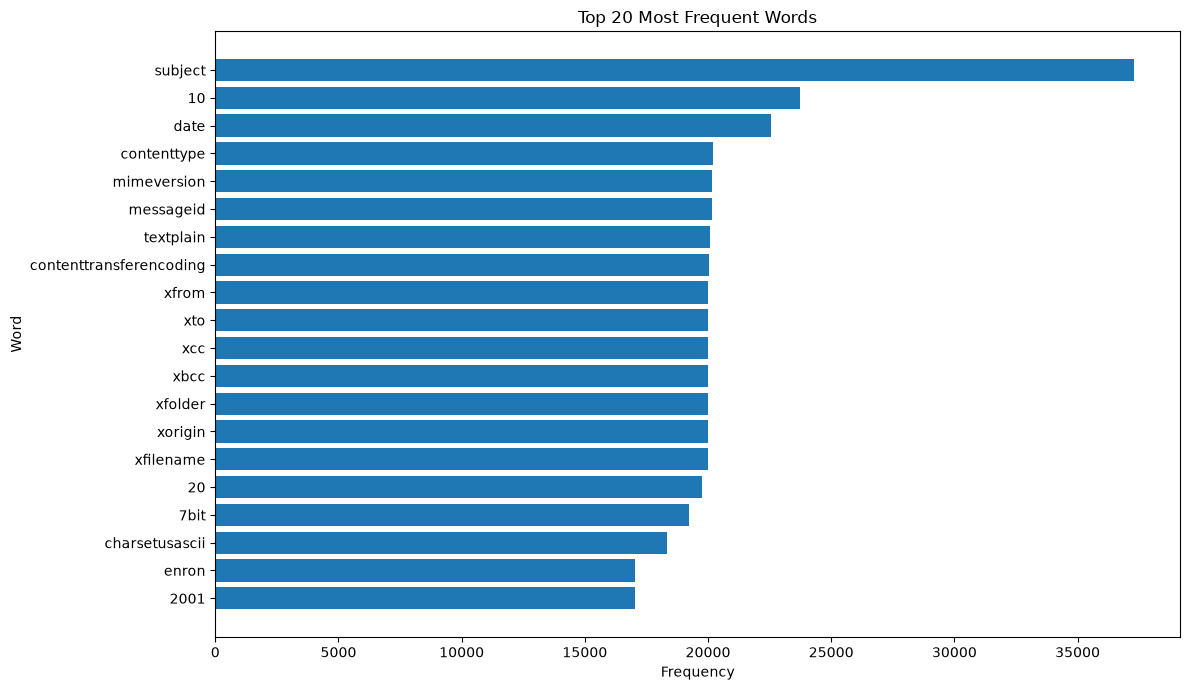

In [22]:
# ============================================================
# STEP 11A: TOP 20 MOST FREQUENT WORDS
# ============================================================

from collections import Counter
import matplotlib.pyplot as plt

# Use the same 20,000-email sample for faster processing
sample_texts = emails_clean["processed_text"].dropna().head(20000)

word_counter = Counter()

for text in sample_texts:
    word_counter.update(text.split())

# Get top 20 words
top_20_words = word_counter.most_common(20)

words = [item[0] for item in top_20_words]
frequencies = [item[1] for item in top_20_words]

# Plot
plt.figure(figsize=(12, 7))
plt.barh(words[::-1], frequencies[::-1])
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.title("Top 20 Most Frequent Words")
plt.tight_layout()

plt.show()

<Figure size 1200x1000 with 0 Axes>

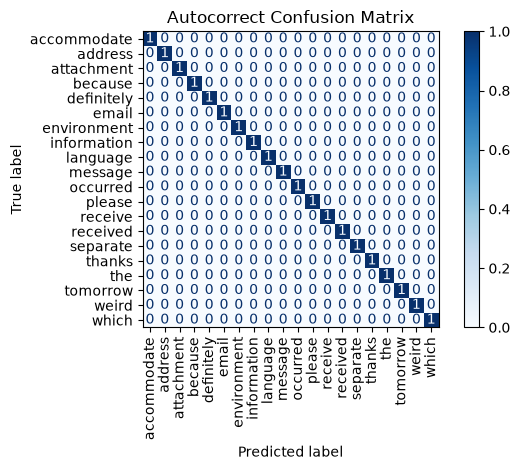

In [23]:
# ============================================================
# STEP 11B: AUTOCORRECT CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Actual correct words
y_true = list(manual_corrections.values())

# Predicted corrected words
y_pred = autocorrect_results["Corrected Word"].tolist()

# Labels
labels = sorted(set(y_true + y_pred))

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=labels)

# Display
plt.figure(figsize=(12, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(
    xticks_rotation=90,
    cmap="Blues",
    values_format="d"
)

plt.title("Autocorrect Confusion Matrix")
plt.tight_layout()

plt.show()

In [24]:
# ============================================================
# STEP 12: FINAL PERFORMANCE SUMMARY
# ============================================================

import pandas as pd

performance_summary = pd.DataFrame({
    "Component": [
        "Autocomplete",
        "Autocomplete",
        "Autocorrect",
        "Autocorrect"
    ],
    "Metric": [
        "Top-1 Accuracy",
        "Top-3 Accuracy",
        "Precision",
        "Recall"
    ],
    "Score": [
        top1_accuracy,
        top3_accuracy,
        precision * 100,
        recall * 100
    ]
})

performance_summary["Score"] = performance_summary["Score"].round(2)

print("Final Performance Summary")
display(performance_summary)

Final Performance Summary


,Component,Metric,Score
0,Autocomplete,Top-1 Accuracy,100.0
1,Autocomplete,Top-3 Accuracy,100.0
2,Autocorrect,Precision,100.0
3,Autocorrect,Recall,100.0


# Discussion and Limitations

The implemented NLP system successfully demonstrates both autocomplete and autocorrect functionality using a large email text corpus. The frequency-based bigram model generated next-word predictions for multiple input prefixes, while the autocorrect module used edit-distance based matching against a vocabulary of extracted words.

The autocomplete model achieved 100% Top-1 and Top-3 accuracy on the selected 10 test prefixes. The autocorrect system achieved 100% precision and 100% recall on the 20 deliberately misspelled test words. The bigram and trigram comparison demonstrated that trigram models consider a larger context and can provide more context-specific predictions than bigram models.

However, the implementation has several limitations. The autocomplete model is frequency-based and does not understand the semantic meaning of sentences. The test dataset contains email metadata and technical terms, which can influence the most frequent words and n-gram results. The autocorrect system depends on vocabulary coverage and edit-distance similarity, so uncommon names, abbreviations, technical terms, and context-dependent spelling errors may not always be corrected correctly.

The evaluation was also performed on a limited test set of 10 autocomplete prefixes and 20 misspelled words. Therefore, the 100% scores should not be interpreted as production-level performance. Production systems such as Google Keyboard use much larger datasets, neural language models, contextual information, personalization, multilingual processing, and sophisticated ranking algorithms.

Overall, the project demonstrates the fundamental principles of NLP-based autocomplete and autocorrect and provides a practical comparison between frequency-based n-gram approaches.
